# BrainBoard — Porównanie Architektur BCI: Klasyczne CSP vs Hybryda Spatio-Temporal

**Cel:** Ewaluacja skuteczności ekstrakcji cech czasowych (Hjorth Mobility/Complexity, Kurtoza) w porównaniu ze standardowym podejściem opartym na filtracji przestrzennej (CSP) w zadaniu klasyfikacji Motor Imagery (L/R). 

**Metodologia:**
Eksperyment przeprowadzony jest wewnątrzosobniczo (**Intra-Subject**) na pełnej populacji zbioru PhysioNet (109 badanych). Dla każdego pacjenta testowane są dwa rurociągi (Pipelines) walidowane za pomocą 5-Fold Stratified Cross-Validation:
1. **Baseline:** Common Spatial Patterns (4 komponenty) + LDA
2. **Hybryda:** CSP (redukcja przestrzenna do 4 źródeł) -> EEGFeatureExtractor (cechy Hjortha i Kurtoza) -> StandardScaler -> LDA

> Dane: PhysioNet EEG Motor Movement/Imagery Dataset (Schalk et al., 2004)  
> Paradygmat: Wewnątrzosobniczy (Intra-Subject), Pasmo 8-30 Hz

In [9]:
import sys, os, numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from joblib import Parallel, delayed
from tqdm.auto import tqdm
from mne.decoding import CSP
from scipy.stats import kurtosis
from sklearn.base import BaseEstimator, TransformerMixin
import mne

# Jupyter directory fix
if os.path.basename(os.getcwd()) == 'notebooks': os.chdir('..')
sys.path.append(os.getcwd())
from src.data.loader import download_dataset, load_raw_subjects
from src.data.preprocessing import epoch_with_params

### Ekstrakcja Cech Czasowych: Parametry Hjortha i Kurtoza

W klasycznym uczeniu maszynowym surowy sygnał jest zbyt złożony dla modeli liniowych. Aby wyciągnąć z niego użyteczne informacje o dynamice i kształcie fali mózgowej bez stosowania ciężkiej transformaty Fouriera, zaimplementowaliśmy niestandardowy transformator `EEGFeatureExtractor`. 

Klasa ta oblicza 4 metryki statystyczne dla każdego kanału w pojedynczej epoce:

**1. Parametry Hjortha (Hjorth, 1970)**
Opisują one właściwości sygnału EEG $X$ w dziedzinie czasu. Algorytm wykorzystuje pierwszą pochodną $X'$ (prędkość zmian) oraz drugą pochodną $X''$ (przyspieszenie zmian).
* **Activity (Wariancja):** Miara całkowitej mocy sygnału.
  $$\text{Activity} = \text{var}(X)$$
* **Mobility:** Przybliżenie średniej częstotliwości (proporcja wariancji pochodnej do wariancji sygnału bazowego).
  $$\text{Mobility} = \sqrt{\frac{\text{var}(X')}{\text{var}(X)}}$$
* **Complexity:** Miara szerokości pasma sygnału (odchylenie kształtu fali od czystej sinusoidy).
  $$\text{Complexity} = \frac{\text{Mobility}(X')}{\text{Mobility}(X)}$$

**2. Kurtoza (Kurtosis)**
Miara "szpiczastości" rozkładu statystycznego sygnału. W kontekście EEG wysoka kurtoza często koreluje z występowaniem artefaktów niefizjologicznych (np. gwałtowne skoki napięcia spowodowane ruchem oka lub mięśni), co dostarcza klasyfikatorowi cennej informacji o czystości danej epoki.

In [10]:
class EEGFeatureExtractor(BaseEstimator, TransformerMixin):
    """Wyciąga Wariancję, Mobility, Complexity i Kurtozę z sygnału."""
    def fit(self, X, y=None): 
        return self

    def transform(self, X):
        eps = 1e-8
        dx = np.diff(X, axis=2)
        ddx = np.diff(dx, axis=2)

        var_x = np.var(X, axis=2)
        var_dx = np.var(dx, axis=2)
        var_ddx = np.var(ddx, axis=2)

        variance = var_x 
        mobility = np.sqrt(var_dx / (var_x + eps))
        complexity = (np.sqrt(var_ddx / (var_dx + eps))) / (mobility + eps)
        kurt = kurtosis(X, axis=2, fisher=True, bias=False)

        features = np.stack([variance, mobility, complexity, kurt], axis=-1)
        
        return features.reshape(X.shape[0], -1)

### Metodologia Ewaluacji: Wewnątrzosobnicza Walidacja Krzyżowa (Intra-Subject CV)

Z uwagi na ogromną zmienność sygnałów EEG pomiędzy różnymi ludźmi, modele budowane są w trybie **Intra-Subject** – dla każdego pacjenta trenowany jest osobny, spersonalizowany klasyfikator. 

Funkcja `evaluate_subject_models` realizuje ustandaryzowany protokół testowy, który gwarantuje sprawiedliwe i rzetelne porównanie obu architektur:

1. **Izolacja Danych i Kontrola Jakości:** Algorytm wycina z głównej macierzy wyłącznie epoki należące do konkretnego pacjenta. Dodatkowo wdrożono mechanizm obronny, który odrzuca pacjentów z brakującymi klasami (np. tylko jeden rodzaj wyobrażenia ruchu) lub zbyt małą liczbą epok (< 10), co zapobiega błędom w obliczeniach statystycznych.
2. **Stratyfikowana Walidacja Krzyżowa (5-Fold CV):** Zbiór pacjenta dzielony jest na 5 losowych, ale zbalansowanych podziałów (`StratifiedKFold`). Gwarantuje to, że w każdym podziale testowym znajduje się proporcjonalna liczba próbek z klasy "Lewa" i "Prawa" ręka. 
3. **Konkurencja Rurociągów (Pipelines):**
   Na tych samych podziałach danych uruchamiane są niezależnie dwa rurociągi:
   * **Baseline (Złoty Standard):** Tradycyjny `CSP` (z ekstrakcją wariancji w skali logarytmicznej) sprzężony bezpośrednio z modelem `LDA` wyposażonym w automatyczną regularyzację (shrinkage).
   * **Hybryda:** `CSP` służący jedynie jako filtr przestrzenny, po którym następuje ekstrakcja nieliniowych cech czasowych (`EEGFeatureExtractor`), ich normalizacja (`StandardScaler`) oraz klasyfikacja (`LDA`).

Wynikiem funkcji jest średnia dokładność (Accuracy) obu modeli z 5 etapów walidacji.

In [11]:
def evaluate_subject_models(sub_id, X, y, subjects):
    """Funkcja trenująca i walidująca dwa modele dla zadanego pacjenta."""
    idx = (subjects == sub_id)
    X_sub, y_sub = X[idx], y[idx]
    
    if len(np.unique(y_sub)) < 2 or len(y_sub) < 10: 
        return None
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    pipe_csp = Pipeline([
        ('CSP', CSP(n_components=4, reg="ledoit_wolf", log=True, norm_trace=False)),
        ('LDA', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))
    ])
    
    pipe_hyb = Pipeline([
        ('CSP', CSP(n_components=4, reg="ledoit_wolf", transform_into='csp_space')),
        ('Hjorth', EEGFeatureExtractor()),
        ('Scaler', StandardScaler()),
        ('LDA', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))
    ])
    
    mne.set_log_level('WARNING')
    
    try:
        score_csp = np.mean(cross_val_score(pipe_csp, X_sub, y_sub, cv=cv, n_jobs=1))
        score_hyb = np.mean(cross_val_score(pipe_hyb, X_sub, y_sub, cv=cv, n_jobs=1))
        return sub_id, score_csp, score_hyb
    except Exception:
        return None

### Uruchomienie Obliczeń i Analiza Wyników

W poniższej komórce następuje właściwe wykonanie zaplanowanego eksperymentu. Proces składa się z trzech etapów:
1. **Wczytanie i Preprocessing:** Pobranie danych 109 pacjentów z repozytorium PhysioNet, wybór 21 elektrod znad kory ruchowej i wycięcie epok czasowych (0.5s - 2.5s) z zastosowaniem filtru pasmowoprzepustowego 8-30 Hz.
2. **Ewaluacja Równoległa:** Uruchomienie funkcji `evaluate_subject_models` przy wykorzystaniu wszystkich dostępnych rdzeni procesora (`joblib.Parallel`), co drastycznie skraca czas obliczeń.
3. **Agregacja Wyników:** Odrzucenie pacjentów z wybrakowanymi danymi, wyodrębnienie grupy **TOP 20%** (tzw. pacjenci *BCI-Literate*, u których występuje silny, fizjologiczny sygnał wyobrażenia ruchu) oraz podliczenie statystyk pojedynków bezpośrednich (Head-to-Head).

In [17]:
print("Pobieranie i wczytywanie zbioru danych")
subjects_data = download_dataset()
raw_data = load_raw_subjects(subjects_data, cache_dir="cache") 

motor_channels = [
    "Fc5.", "Fc3.", "Fc1.", "Fcz.", "Fc2.", "Fc4.", "Fc6.",
    "C5..", "C3..", "C1..", "Cz..", "C2..", "C4..", "C6..",
    "Cp5.", "Cp3.", "Cp1.", "Cpz.", "Cp2.", "Cp4.", "Cp6."
]

print("\nEpokowanie i filtrowanie")
X, y, subjects = epoch_with_params(
    raw_data,
    channels=motor_channels,
    low_freq=8.0,
    high_freq=30.0,
    tmin=0.5,
    tmax=2.5,
    task_mode="binary",
    seed=42
)


unique_subs = np.unique(subjects)
print(f"\nRozpoczynam ewaluację dla {len(unique_subs)} pacjentów")

results = Parallel(n_jobs=-1)(
    delayed(evaluate_subject_models)(s, X, y, subjects) 
    for s in tqdm(unique_subs, desc="Obliczanie modeli")
)

valid_results = [r for r in results if r is not None]

acc_csp = [r[1] for r in valid_results]
acc_hjorth = [r[2] for r in valid_results]

valid_results.sort(key=lambda x: x[1], reverse=True)
top_20_idx = max(1, int(len(valid_results) * 0.2))

acc_csp_top20 = [r[1] for r in valid_results[:top_20_idx]]
acc_hjorth_top20 = [r[2] for r in valid_results[:top_20_idx]]

print('='*50)
print(f"Średnia WSZYSTKICH:   CSP = {np.mean(acc_csp)*100:.2f}% | Hjorth = {np.mean(acc_hjorth)*100:.2f}%")
print(f"Średnia TOP 20%:      CSP = {np.mean(acc_csp_top20)*100:.2f}% | Hjorth = {np.mean(acc_hjorth_top20)*100:.2f}%")
print("="*50)

wins = sum(1 for r in valid_results if r[2] > r[1])
ties = sum(1 for r in valid_results if r[2] == r[1])
losses = len(valid_results) - wins - ties

print(f"\n\n" + "="*50)
print(f"Parametry hjortha")
print(f"Lepsze od CSP dla:      {wins} pacjentów")
print(f"Takie same jak CPS dla: {ties} pacjentów")
print(f"Gorsza od CSP dla:      {losses} pacjentów")
print("="*50)

Pobieranie i wczytywanie zbioru danych
Dataset path: /home/jovyan/.cache/kagglehub/datasets/brianleung2020/eeg-motor-movementimagery-dataset/versions/1
Found 109 subjects
Loading cached raw data from cache/raw_data.pkl
Loaded 106 subjects from cache

Epokowanie i filtrowanie

Rozpoczynam ewaluację dla 106 pacjentów


Obliczanie modeli:   0%|          | 0/106 [00:00<?, ?it/s]

Średnia WSZYSTKICH:   CSP = 60.77% | Hjorth = 60.44%
Średnia TOP 20%:      CSP = 85.93% | Hjorth = 82.33%


Parametry hjortha
Lepsze od CSP dla:      48 pacjentów
Takie same jak CPS dla: 10 pacjentów
Gorsza od CSP dla:      48 pacjentów


### Wnioski z Eksperymentu i Decyzja Architektoniczna

Po przeprowadzeniu ewaluacji wewnątrzosobniczej na 106 próbkach z bazy PhysioNet, wyciągnięto następujące wnioski:

1. **Przewaga CSP:** W grupie pacjentów wykazujących najwyższą podatność na interfejsy BCI, czyli TOP 20%, klasyczny pipeline CSP + LDA osiągnął skuteczność na poziomie **85.93%**, wygrywając z parametrami hjortha, gdzie skuteczność wyniosła **82.33%**.
2. **Szum informacyjny cech nieliniowych:** Statystyki badnia, które wykazują, że parametry hjortha dają lepszy wynik dla 48 osób, gorsze dla 48, oraz takie same dla 10 wskazują, że parametry Hjortha i Kurtoza dodane do przefiltrowanego sygnału nie wnoszą stabilnej wartości predykcyjnej. Zamiast tego wprowadzają redundancję, która u połowy populacji dezorientuje model klasyfikujący. Wariancja sygnału, wyodrębniana w sposób naturalny przez macierze kowariancji w CSP, okazuje się w pełni wystarczająca.

Text(0.5, 1.0, 'Rozkład Przewagi Predykcyjnej')

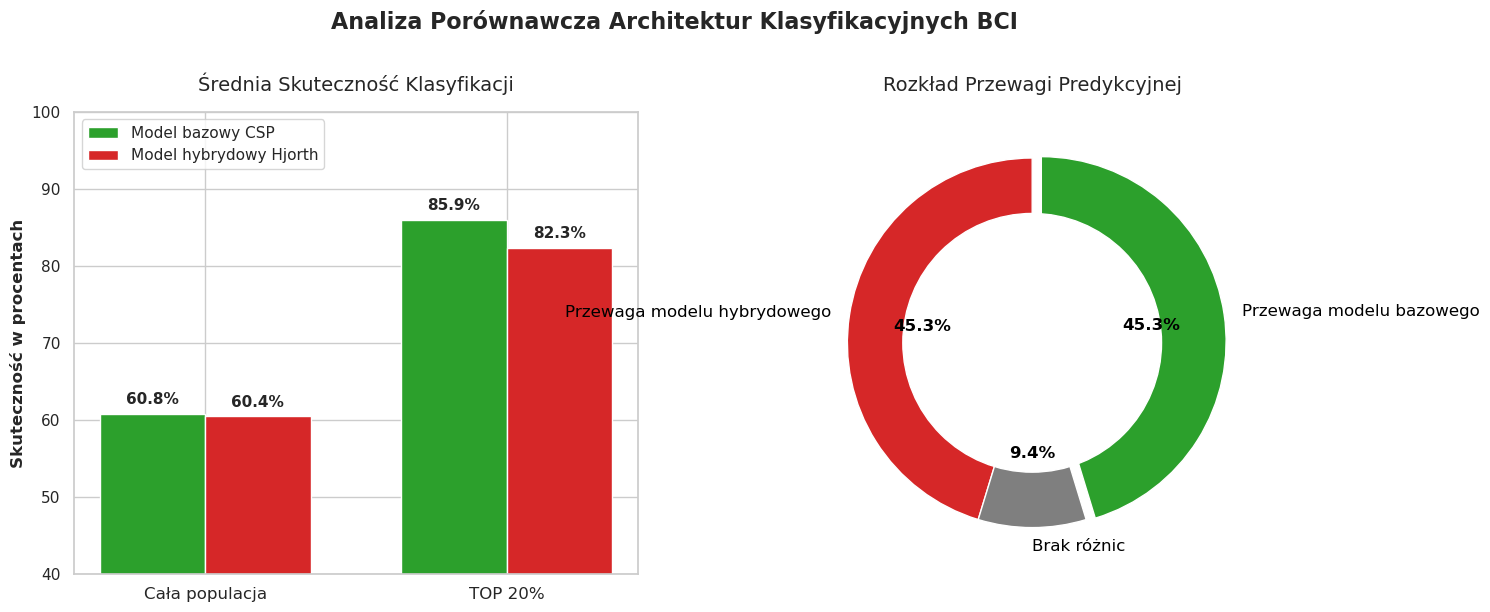

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

categories = ['Cała populacja', 'TOP 20%']
csp_scores = [np.mean(acc_csp)*100, np.mean(acc_csp_top20)*100]
hjorth_scores = [np.mean(acc_hjorth)*100, np.mean(acc_hjorth_top20)*100]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analiza Porównawcza Architektur Klasyfikacyjnych BCI', fontsize=16, fontweight='bold', y=1.05)

x = np.arange(len(categories))
width = 0.35

rects1 = ax1.bar(x - width/2, csp_scores, width, label='Model bazowy CSP', color='#2ca02c')
rects2 = ax1.bar(x + width/2, hjorth_scores, width, label='Model hybrydowy Hjorth', color='#d62728')

ax1.set_ylabel('Skuteczność w procentach', fontsize=12, fontweight='bold')
ax1.set_title('Średnia Skuteczność Klasyfikacji', fontsize=14, pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=12)
ax1.set_ylim([40, 100])
ax1.legend(loc='upper left')

def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

autolabel(rects1, ax1)
autolabel(rects2, ax1)

labels = ['Przewaga modelu hybrydowego', 'Brak różnic', 'Przewaga modelu bazowego']
sizes = [wins, ties, losses]
colors = ['#d62728', '#7f7f7f', '#2ca02c']
explode = (0, 0, 0.05)

wedges, texts, autotexts = ax2.pie(sizes, explode=explode, labels=labels, colors=colors, 
                                   autopct='%1.1f%%', startangle=90)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

for text in texts:
    text.set_color('black')
    text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

ax2.set_title('Rozkład Przewagi Predykcyjnej', fontsize=14, pad=15)